# **PROJECT_TITLE: E_COMMERCE_DELIVERY_PREDICTION**

## **Business Objective**
## 🎯 Business Objective

The objective of this project is to develop a machine learning classification model to predict whether an e-commerce product delivery will be delayed or delivered on time.By identifying high-risk shipments in advance, the company can take proactive actions to improve delivery reliability, optimize logistics, and enhance customer satisfaction..

## **Project Benefits** 

- **Delivery Optimization:** Identify key factors affecting delivery delays and improve logistics planning  
- **Customer Satisfaction:** Set accurate delivery expectations and reduce customer complaints  
- **Operational Insights:** Enable better decision-making using data-driven insights  

## **Potential Business Actions**
- Prioritize high-risk shipments in warehouse processing
- Change shipping method for orders predicted to be delayed
- Improve logistics planning and resource allocation
- Inform customers proactively about potential delays

# **Section_1: Install Required Python Libraries**

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.


# **Section_2: Import Libraries**

In [2]:
#Data Handling
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# **Section_3 Load Dataset**

In [3]:
df = pd.read_excel(r"C:\Users\shelm\OneDrive\Desktop\Capstone project_Ecommerce_Delivery_prediction\E_Commerce.xlsx")
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


# **Section_4: Data Inspection**

## Data Inspection

- Dataset shape and structure examined  
- Data types verified  
- Summary statistics analyzed  
- Missing values checked  

In [4]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()
df = df.drop(columns=["ID"], errors='ignore')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


*The dataset contains no missing values across all features.
Therefore, no imputation or missing value handling is required during preprocessing.*

**Feature Description Table Below**

| Feature             | Description                                            |
| ------------------- | ------------------------------------------------------ |
| ID                  | Unique identifier for each customer                    |
| Warehouse_block     | Warehouse location block (A–E)                         |
| Mode_of_Shipment    | Shipping method used (Ship, Flight, Road)              |
| Customer_care_calls | Number of customer service calls related to shipment   |
| Customer_rating     | Rating provided by the customer (1–5)                  |
| Cost_of_the_Product | Cost of the product in USD                             |
| Prior_purchases     | Number of previous purchases by the customer           |
| Product_importance  | Importance category of the product (Low, Medium, High) |
| Gender              | Gender of the customer                                 |
| Discount_offered    | Discount applied to the product                        |
| Weight_in_gms       | Product weight in grams                                |
| Reached.on.Time_Y.N | Target variable indicating delivery status             |


## Target Variable
**Reached.on.Time_Y.N**

- 0 → Product delivered on time
- 1 → Product delivered late

# **Section_5: Exploratory Data Analysis**

**1.EDA_Target Variable Distribution**

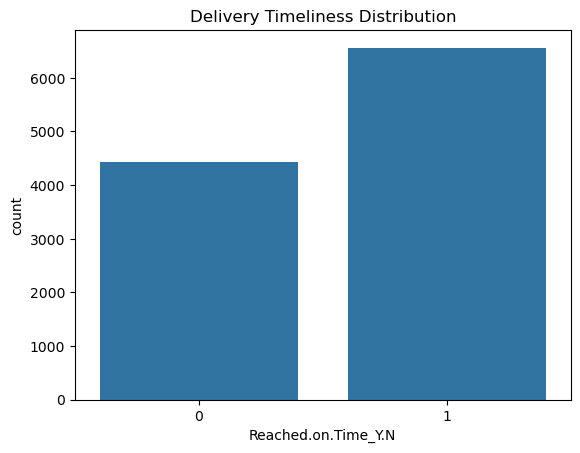

In [5]:
sns.countplot(x="Reached.on.Time_Y.N", data=df)
plt.title("Delivery Timeliness Distribution")
plt.show()
#0 → Product delivered on time 
#1 → Product delivered late

- 0 → Delivered on time
- 1 → Delivered late  
The dataset shows a higher number of delayed deliveries compared to on-time deliveries, indicating a class imbalance and highlighting delivery delays as a key operational concern.

**2.EDA_Shipment Mode Distribution**

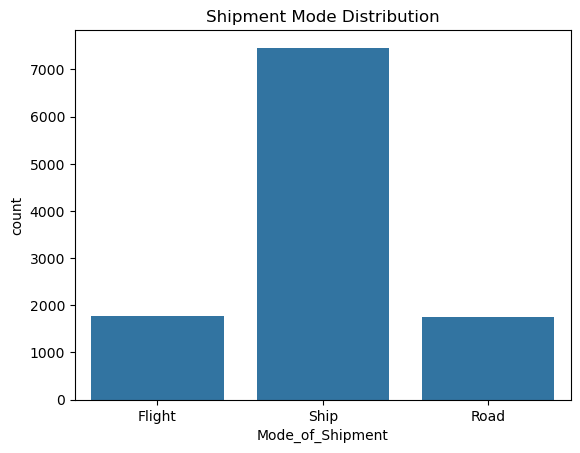

In [6]:
sns.countplot(x="Mode_of_Shipment", data=df)
plt.title("Shipment Mode Distribution")
plt.show()

**The visualization shows that the majority of shipments are transported using Ship mode, followed by Road and Flight. This suggests that the company relies heavily on ship-based transportation for product deliveries. Since shipping typically takes longer compared to air transport, this may contribute to delivery delays.**

**3.EDA_Warehouse Performance**

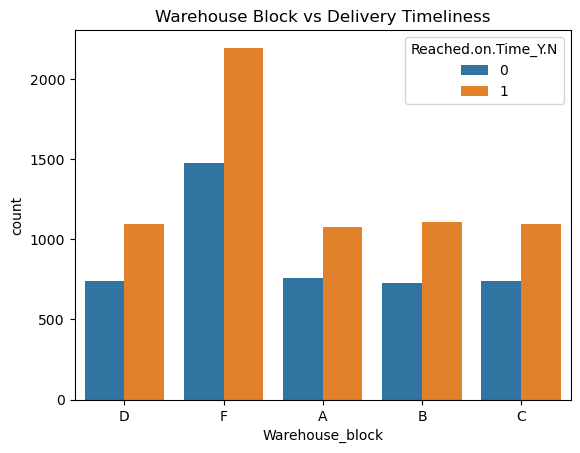

In [7]:
sns.countplot(x="Warehouse_block", hue="Reached.on.Time_Y.N", data=df)
plt.title("Warehouse Block vs Delivery Timeliness")
plt.show()

**0 → Product delivered on time
1 → Product delivered late**

In [8]:
df["Warehouse_block"].unique()

array(['D', 'F', 'A', 'B', 'C'], dtype=object)

Note:
The dataset documentation indicates that warehouse blocks range from A–E.
However, the actual dataset contains the following warehouse blocks:A, B, C, D, and F.

This discrepancy suggests that the documentation may contain a minor error, and the analysis will rely on the values present in the dataset.

**The visualization shows that Warehouse Block F has the highest number of delayed deliveries compared to the other warehouse blocks 
and have higher shipment volumes, operational inefficiencies, or logistical constraints associated with this warehouse. 
Identifying such warehouse-level patterns can help the company focus on improving operations at specific locations to reduce delivery delays.**

**The distribution of shipments across warehouse blocks shows that Warehouse Block F handles a significantly higher number of orders compared
to the other warehouses. Warehouses A, B, C, and D appear to have relatively balanced shipment volumes.**

**The higher shipment volume in Warehouse F may indicate increased operational workload, which could potentially contribute to delivery delays. Understanding warehouse workload distribution helps identify possible logistics bottlenecks in the delivery network.**

**4.EDA_Shipment Mode vs Delivery Delay**

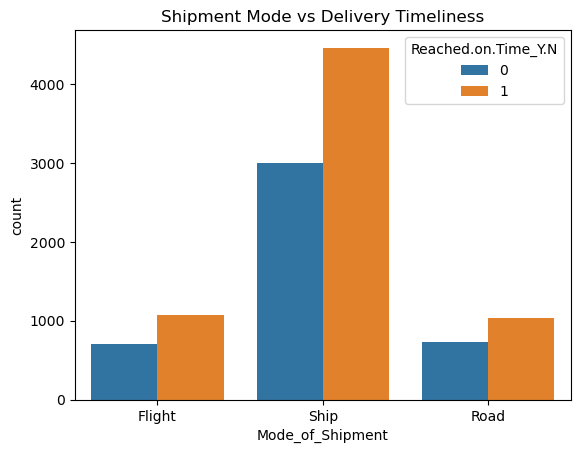

In [9]:
sns.countplot(x="Mode_of_Shipment", hue="Reached.on.Time_Y.N", data=df)
plt.title("Shipment Mode vs Delivery Timeliness")
plt.show()

**The visualization shows that shipments transported by Ship have the highest number of delayed deliveries compared to Road and Flight.Since ship transport typically involves longer transit times, it may increase the likelihood of delivery delays.This suggests that the shipment mode is an important factor influencing delivery performance and should be considered when building the 
prediction model.**

**5.EDA_Discount Offered vs Delivery Delay.**

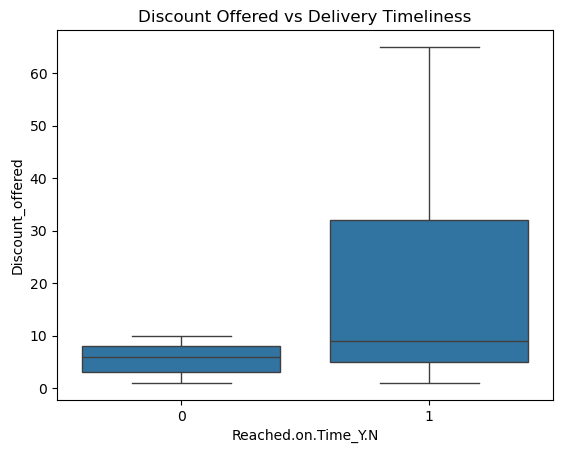

In [10]:
sns.boxplot(x="Reached.on.Time_Y.N", y="Discount_offered", data=df)
plt.title("Discount Offered vs Delivery Timeliness")
plt.show()

**The boxplot shows that delayed deliveries (class 1) generally have higher discount values compared to on-time deliveries (class 0). This may indicate
that high discount offers lead to increased order volumes during promotional periods, which can place additional pressure on warehouse and logistics
operations, increasing the likelihood of delivery delays.**

**6.EDA_Product Weight vs Delivery Delay**

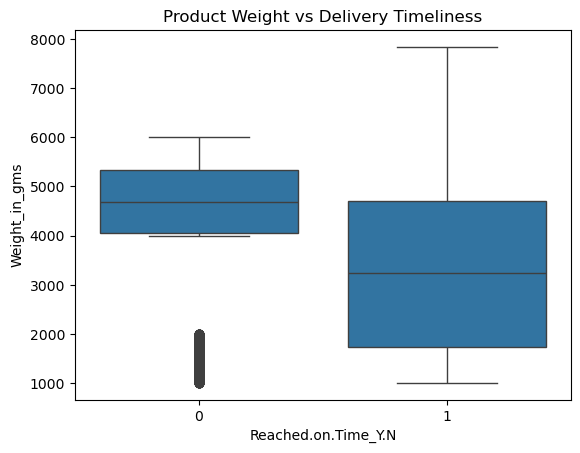

In [11]:
sns.boxplot(x="Reached.on.Time_Y.N", y="Weight_in_gms", data=df)
plt.title("Product Weight vs Delivery Timeliness")
plt.show()

**The boxplot shows that on-time deliveries (class 0) tend to involve heavier products compared to delayed deliveries (class 1). The median
weight for on-time deliveries is noticeably higher than for delayed deliveries. This suggests that heavier products may receive more
careful handling or priority logistics, while lighter products may experience delays due to higher shipment volumes.**

**7.EDA_Correlation Heatmap**

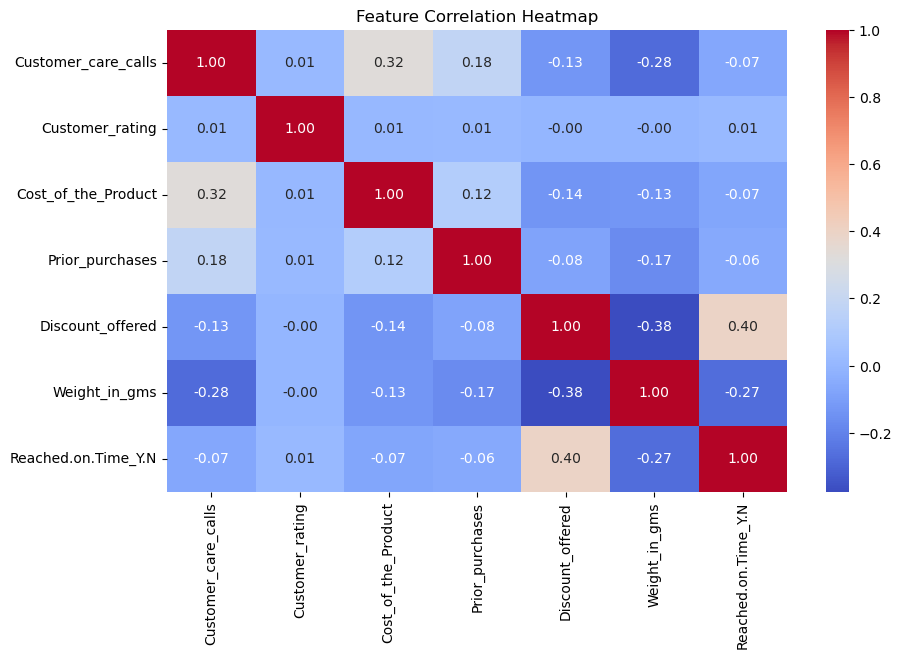

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

**Common observations in this dataset:**
- Discount_offered → positive correlation with delays
- Weight_in_gms → negative correlation with delays
- Most other variables show weak correlations

The correlation heatmap shows relationships between the numerical features in the dataset. Most variables exhibit weak correlations with the 
target variable (Reached.on.Time_Y.N), indicating thatdelivery delays are influenced by multiple factors rather than a single dominant variable.
However, Discount_offered shows a noticeable positive correlationwith delayed deliveries, supporting earlier EDA findings that
higher discounts tend to be associated with delivery delays.

Weight_in_gms shows a slight negative correlation with delays, suggesting that heavier products are not necessarily more likely to be delayed.
Although categorical variables are encoded numerically for the purpose of correlation analysis, earlier exploratory analysis indicated that Warehouse Block F processes a slightly higher number of shipments compared to other warehouses, which maycontribute to higher observed delays due to increased operational workload.


**EDA revealed that discount, shipment mode, and warehouse load significantly influence delivery delays, which guided feature engineering and model selection.**

# **Section_6: Feature Engineering and Data Preparation**

**Step_1:Encoding Categorical Variables**
#Machine learning models cannot process text categories.In this step we will be changing categorical columns to numerical coloumns using label encoder.
Categorical columns in dataset are:Warehouse_block, Mode_of_Shipment, Product_importance, and Gender.Except for product_importance column rest all doesnt have ordinality. 

**We will be doing**
- Product_importance → Ordinal Encoding (has natural order)
- Warehouse_block → One-Hot Encoding
- Mode_of_Shipment → One-Hot Encoding
- Gender → One-Hot Encoding

In [13]:
#Step_1:Ordinal Encoding for Product Importance
df["Product_importance"] = df["Product_importance"].map({
    "low": 0,
    "medium": 1,
    "high": 2
})
print(df["Product_importance"].unique())

[0 1 2]


In [14]:
# Step 2: One-Hot Encoding for Remaining Categorical Variables

cols_to_encode = ["Warehouse_block", "Mode_of_Shipment", "Gender"]

# check which columns still exist in dataframe
existing_cols = [col for col in cols_to_encode if col in df.columns]

# apply encoding only if columns exist
if existing_cols:
    df = pd.get_dummies(df, columns=existing_cols, drop_first=True)

df.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,4,2,177,3,0,44,1233,1,False,False,True,False,False,False,False
1,4,5,216,2,0,59,3088,1,False,False,False,True,False,False,True
2,2,2,183,4,0,48,3374,1,False,False,False,False,False,False,True
3,3,3,176,4,1,10,1177,1,True,False,False,False,False,False,True
4,2,2,184,3,1,46,2484,1,False,True,False,False,False,False,False


Data preprocessing steps such as ordinal encoding and one hot encoding were applied only to the input features and did not use the target variable. 
Since no target-based transformations or scaling operations were performed before splitting the dataset, 
the preprocessing does not introduce data leakage.

**Step_2: Preparing Feature Matrix and Target Variable**

In [15]:
# X = features, y = target

y = df["Reached.on.Time_Y.N"]

#Dropping the column customer_care_calls for possible target leakage.
#Experiment: Drop Customer_care_calls
X = df.drop(["Reached.on.Time_Y.N", "Customer_care_calls"], axis=1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (10999, 13)
Shape of y: (10999,)


In [16]:
X.head()

,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,2,177,3,0,44,1233,False,False,True,False,False,False,False
1,5,216,2,0,59,3088,False,False,False,True,False,False,True
2,2,183,4,0,48,3374,False,False,False,False,False,False,True
3,3,176,4,1,10,1177,True,False,False,False,False,False,True
4,2,184,3,1,46,2484,False,True,False,False,False,False,False


The dataset was divided into input features (X) and the target variable (y).
The target variable Reached.on.Time_Y.N indicates whether a delivery was delayed (1) or delivered on time (0). 
Feature Experiment: Customer Care Calls
Customer_care_calls may introduce target leakage, as customers may contact support after experiencing delays.
To validate this, the feature is removed and model performance will be compared.

**Step_3: Train–Test Split**

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42,stratify=y)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print(df.isnull().sum())


Training set: (8799, 13)
Testing set: (2200, 13)
Customer_care_calls      0
Customer_rating          0
Cost_of_the_Product      0
Prior_purchases          0
Product_importance       0
Discount_offered         0
Weight_in_gms            0
Reached.on.Time_Y.N      0
Warehouse_block_B        0
Warehouse_block_C        0
Warehouse_block_D        0
Warehouse_block_F        0
Mode_of_Shipment_Road    0
Mode_of_Shipment_Ship    0
Gender_M                 0
dtype: int64


*The dataset was split into training and testing sets using an 80–20 ratio.
The training set is used to train the machine learning models, while the
testing set is used to evaluate their performance on unseen data.*

**Step_4: Model_Training**

# **1: LogisticRegression Model**

C:\Users\shelm\.ipython\aanaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.6522727272727272

Confusion Matrix:
[[759 128]
 [637 676]]


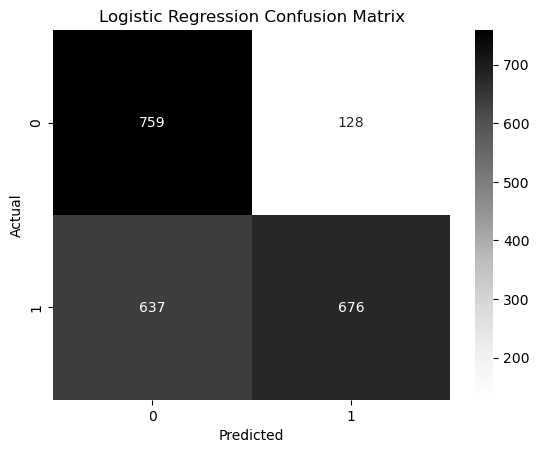


Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.86      0.66       887
           1       0.84      0.51      0.64      1313

    accuracy                           0.65      2200
   macro avg       0.69      0.69      0.65      2200
weighted avg       0.72      0.65      0.65      2200



In [18]:
#import
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#train
logistic_regression_model = LogisticRegression(max_iter=1000,class_weight='balanced') #if class weight is being  used class_weight={0:1, 1:3}.
logistic_regression_model.fit(X_train, y_train)

#probabilities
#y_probs_logistic_regression =logistic_regression_model.predict_proba(X_test)[:,1]
#Apply threshold
#threshold = 0.4
#y_pred_logistic_regression = (y_probs_logistic_regression >= threshold).astype(int)

#if no threshold is being applied then 
y_pred = logistic_regression_model.predict(X_test)

#Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

#ConfusionMatrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt="d", cmap="Greys")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

**The Logistic Regression model achieved moderate accuracy and showed better performance in identifying delayed deliveries compared to on-time deliveries.**

# **2: DecisionTree Model**

Decision Tree Accuracy: 0.6277272727272727

Confusion Matrix:
[[479 408]
 [411 902]]


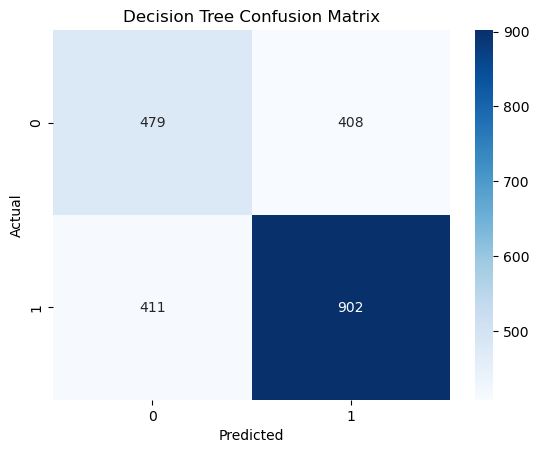


Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.54      0.54       887
           1       0.69      0.69      0.69      1313

    accuracy                           0.63      2200
   macro avg       0.61      0.61      0.61      2200
weighted avg       0.63      0.63      0.63      2200



In [22]:
#Import 
from sklearn.tree import DecisionTreeClassifier

#Train
decision_tree_model = DecisionTreeClassifier(random_state=0,class_weight='balanced') #class_weight='balanced' if no class weight is being  used.
decision_tree_model.fit(X_train, y_train)

#Probabilities
#y_probs_Decision_Tree =decision_tree_model.predict_proba(X_test)[:,1]
#threshold = 0.4
#y_pred_Decision_Tree = (y_probs_Decision_Tree >= threshold).astype(int)

#if no threshold is being applied then 
y_pred = decision_tree_model.predict(X_test)

#Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

**The Decision Tree model achieved similar performance to Logistic Regression but did not significantly improve predictive capability.**

# **3: RandomForest Model**

In [29]:
#Experiment: GridSearchCV_Randomforest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5,scoring='recall') # we need to focus on recall for delayed class

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': 20, 'n_estimators': 50}
Best Score: 0.6474285714285715


**Hyperparameter Tuning**
GridSearchCV was applied to the Random Forest model to identify optimal hyperparameters.
The tuning process explored different values for:
- Number of estimators (n_estimators)
- Maximum tree depth (max_depth)
The best parameters obtained helped improve model generalization, although the performance gain was marginal, indicating that the baseline model was already well-tuned.

Accuracy: 0.6627272727272727

Confusion Matrix:
[[613 274]
 [468 845]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.69      0.62       887
           1       0.76      0.64      0.69      1313

    accuracy                           0.66      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.66      0.67      2200



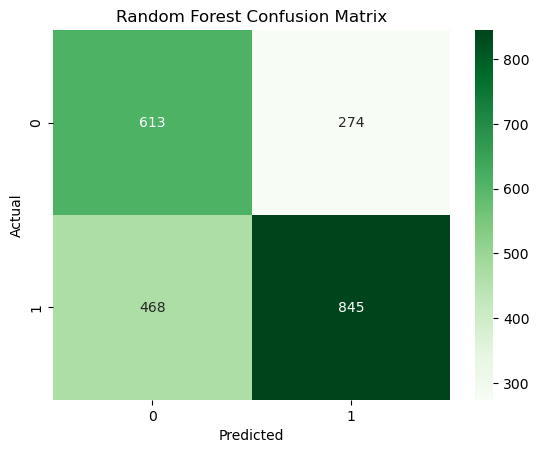

In [28]:
# import libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# Step 1: Train model with custom class weights
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    class_weight='balanced',  # if Increased importance for delayed class, class_weight={0:1, 1:3} 
    random_state=42
)

rf_model.fit(X_train, y_train)

# Step 2: Get probabilities instead of direct predictions
#y_probs = rf_model.predict_proba(X_test)[:, 1]

# Step 3: Apply custom threshold
#threshold = 0.4  # Lower than 0.5 to improve recall
#y_pred_random_forest = (y_probs >= threshold).astype(int)

#if no threshold is being applied then 
y_pred = rf_model.predict(X_test)

# Step 4: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Random Forest achieved the highest accuracy among all models, demonstrating its ability to capture complex patterns and interactions in the data.**

# **Random Forest Feature Importance Chart and Visualisation**

In [24]:
#Random Forest allows you to see which features influence delays most.
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Discount_offered         0.424970
Weight_in_gms            0.319610
Cost_of_the_Product      0.096096
Prior_purchases          0.068699
Customer_rating          0.024333
Product_importance       0.016552
Gender_M                 0.010113
Mode_of_Shipment_Ship    0.007571
Mode_of_Shipment_Road    0.007090
Warehouse_block_F        0.006870
Warehouse_block_C        0.006154
Warehouse_block_D        0.006113
Warehouse_block_B        0.005828
dtype: float64


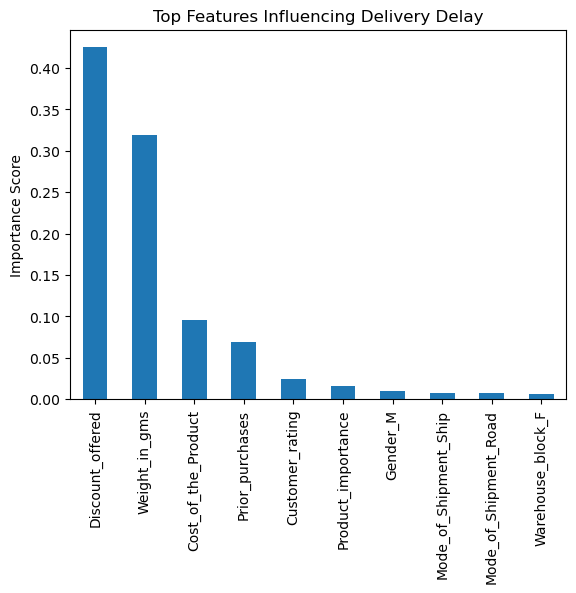

In [25]:
feature_importance.head(10).plot(kind="bar")

plt.title("Top Features Influencing Delivery Delay")
plt.ylabel("Importance Score")

plt.show()

**Feature importance analysis shows that Discount_offered and Weight_in_gms are key drivers of delivery delays.
Higher discounts may increase order volumes, putting pressure on logistics systems, while product weight influences handling and transportation complexity.**

# **4: KNN Model**





KNN Accuracy: 0.6468181818181818

Confusion Matrix:
[[544 343]
 [434 879]]


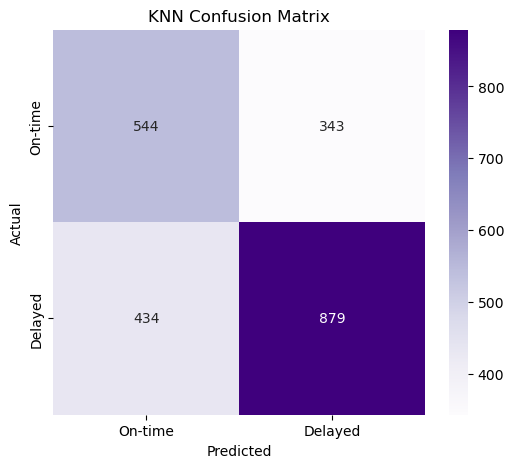


Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.61      0.58       887
           1       0.72      0.67      0.69      1313

    accuracy                           0.65      2200
   macro avg       0.64      0.64      0.64      2200
weighted avg       0.65      0.65      0.65      2200



In [26]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predictions
knn_pred = knn_model.predict(X_test_scaled)

# Accuracy
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

# Confusion Matrix (print)
cm = confusion_matrix(y_test, knn_pred)

print("\nConfusion Matrix:")
print(cm)

# Confusion Matrix (plot)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["On-time", "Delayed"],
            yticklabels=["On-time", "Delayed"])

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

**The K-Nearest Neighbors (KNN) model achieved an accuracy of approximately 64.68%, performing slightly lower than Logistic Regression and Random Forest, but better than the Decision Tree model.The model demonstrated moderate performance in identifying delayed deliveries, but it still misses a notable number of delayed shipments, as indicated by false negatives.Since KNN is a distance-based algorithm, its performance is highly sensitive to feature scaling and the distribution of data. Additionally, it can be computationally expensive for large datasets and less efficient for real-time prediction systems.Overall, while KNN provides reasonable performance, it does not outperform Logistic Regression or Random Forest and is not the most suitable model for this problem.**

# Model Comparison Chart

| Model               | Accuracy |
|---------------------|----------|
| Random Forest       | 0.6804   |      
| KNN                 | 0.6468   |
| Logistic Regression | 0.6522   |
| Decision Tree       | 0.6277   |

Random Forest performs better than a Decision Tree because it combines multiple trees and averages their predictions, which reduces overfitting 
and improves generalization. A single Decision Tree can easily overfit the training data, while Random Forest reduces this variance by using multiple trees trained on different subsets of data.But in this use case we need to focus on recall for delayed class so adjusted the scoring to recall and achieved accuracy of 0.6627 with improved FN and increased false alarms.I used recall as the scoring metric because the business objective is to minimize missed delays, making recall more important than accuracy.

### Model Training and Evaluation Summary

Multiple machine learning models were trained and evaluated, including:
- Logistic Regression  
- Decision Tree  
- Random Forest  
- K-Nearest Neighbors (KNN)  

Among these, **Random Forest achieved the highest accuracy (~68%)**, outperforming all other models.

Logistic Regression provided a strong baseline, while KNN and Decision Tree showed moderate performance but did not significantly improve results.

### Model Improvements and Validation

- **Feature Validation:**  
  The `Customer_care_calls` feature was removed to check for potential data leakage. This slightly reduced accuracy but ensured a more reliable and unbiased model.

- **Hyperparameter Tuning:**  
  GridSearchCV was applied to optimize Random Forest parameters, resulting in marginal performance improvement.

- **Cross-Validation:**  
  Stratified K-Fold cross-validation was used to ensure robust evaluation by maintaining class distribution across folds.

- **Feature Scaling:**  
  Scaling was applied for KNN to improve distance-based learning, leading to better performance compared to its unscaled version.

### Model Trade-Off Analysis

Different modeling strategies were tested to balance business objectives:

- Applying class weighting reduced false positives but increased false negatives  
- Lower thresholds improved recall but caused overprediction of delays  

This highlights an important trade-off:
- Minimizing false positives → reduces operational cost  
- Minimizing false negatives → improves delay detection  

The final model selection depends on business priorities.  

### Final Model Selection

Random Forest was selected as the final model due to:

- Highest accuracy among all models  
- Ability to capture complex feature interactions  
- Robust performance across validation techniques  
- Interpretability through feature importance  

Although aggressive class balancing improved recall, it led to excessive false positives. Therefore, a balanced configuration was chosen to maintain overall model reliability.

### Business Insights

Feature importance analysis revealed key drivers of delivery delays:

- **Discount_offered:** Higher discounts are associated with increased delays, likely due to surge in order volume  
- **Weight_in_gms:** Product weight impacts logistics complexity and handling  
- **Warehouse_block & Shipment mode:** Operational factors influence delivery performance  

These insights can help optimize logistics and planning.

Applying class balancing reduced false positives significantly but increased missed delays. 
Since detecting delays is more critical for business impact, the original tuned Random Forest model was retained as the final model.

### Final Recommendation

Since the primary business objective is to reduce customer dissatisfaction due to delays, the model should prioritize identifying delayed deliveries.

Recommended actions:
- Prioritize high-risk shipments for faster processing  
- Adjust shipping methods for predicted delays  
- Improve warehouse operations for high-load locations  
- Notify customers proactively about potential delays  

This approach enables proactive decision-making and improves overall delivery reliability.